In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/freelancer/railway

/content/drive/MyDrive/freelancer/railway


In [ ]:
#!uv pip install tensorflowjs

Using Python 3.11.13 environment at: /usr
Resolved 67 packages in 831ms
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
packaging  ------------------------------ 48.00 KiB/51.77 KiB
⠙ Preparing packages... (0/2)
packaging  ------------------------------ 51.77 KiB/51.77 KiB
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
Prepared 2 packages in 31ms
Uninstalled 1 package in 4ms
Installed 2 packages in 5ms
 - packaging==24.2
 + packaging==23.2
 + tensorflowjs==4.22.0


In [ ]:
!tensorflowjs_converter --input_format keras model_cnn.h5 model/

2025-06-12 07:49:14.762722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749714554.807679    1371 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749714554.818180    1371 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-12 07:49:14.850210: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training

# Importing all the required libraries

In [ ]:
!uv pip install efficientnet # it is pretrained model

Using Python 3.11.13 environment at: /usr
Resolved 12 packages in 392ms
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
efficientnet ------------------------------     0 B/17.99 KiB
⠙ Preparing packages... (0/2)
efficientnet ------------------------------     0 B/17.99 KiB
⠙ Preparing packages... (0/2)
efficientnet ------------------------------     0 B/17.99 KiB
⠙ Preparing packages... (0/2)
efficientnet ------------------------------     0 B/17.99 KiB
⠙ Preparing packages... (0/2)
efficientnet ------------------------------     0 B/17.99 KiB
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
Prepared 2 packages in 26ms
Installed 2 packages in 3ms
 + efficientnet==1.1.1
 + keras-applications==1.0.8


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import os
import seaborn as sns
import pandas as pd
from skimage.io import imshow, imread


from sklearn.model_selection import train_test_split
import efficientnet.keras as effnet
from tensorflow.keras import models, layers


import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization
from keras.layers import Activation, Flatten, Dropout, Dense
from keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
import seaborn as sns
from keras import applications
from keras import callbacks
from keras.models import Sequential
from tensorflow.keras.applications import ResNet50V2 # 50 hidden layer
from tensorflow.keras import models, layers

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop, SGD, Adam
import keras
from tensorflow.keras.models import load_model


from sklearn.metrics import classification_report
from tensorflow.keras.applications import VGG16 # Visual Geometry Group 16 hidden layer
from keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# specifying the path of the dataset
path='dataset/'

In [ ]:
# checing the folder names in the path directory
folder_names = os.listdir(path)
folder_names

['rails.csv', 'valid', 'test', 'train']

In [ ]:
train_path='dataset/train'
test_path='dataset/test'
val_path='dataset/valid'

# checking the number of classes
class_names = os.listdir(train_path)
class_names

['Non defective', 'Defective']

# Plotting few of images of the defective railway tracks

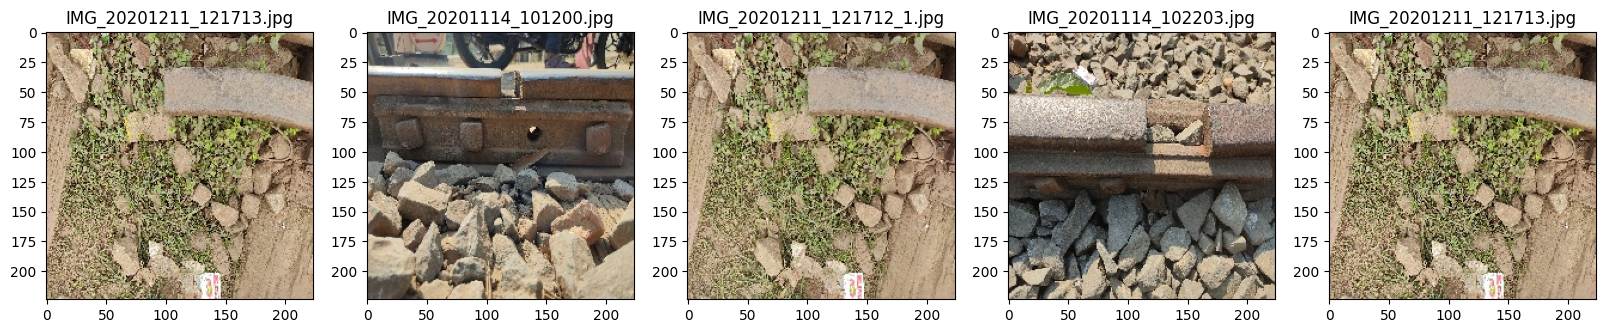

In [ ]:
import random
import matplotlib.image as mpimg
plt.figure(figsize=(20,20))
img_folder='dataset/test/Defective'
for i in range(5):
    file = random.choice(os.listdir(img_folder))
    image_path= os.path.join(img_folder, file)
    img=mpimg.imread(image_path)
    ax=plt.subplot(1,5,i+1)
    ax.title.set_text(file)
    plt.imshow(img)

# Plotting few of images of the non defective railway tracks

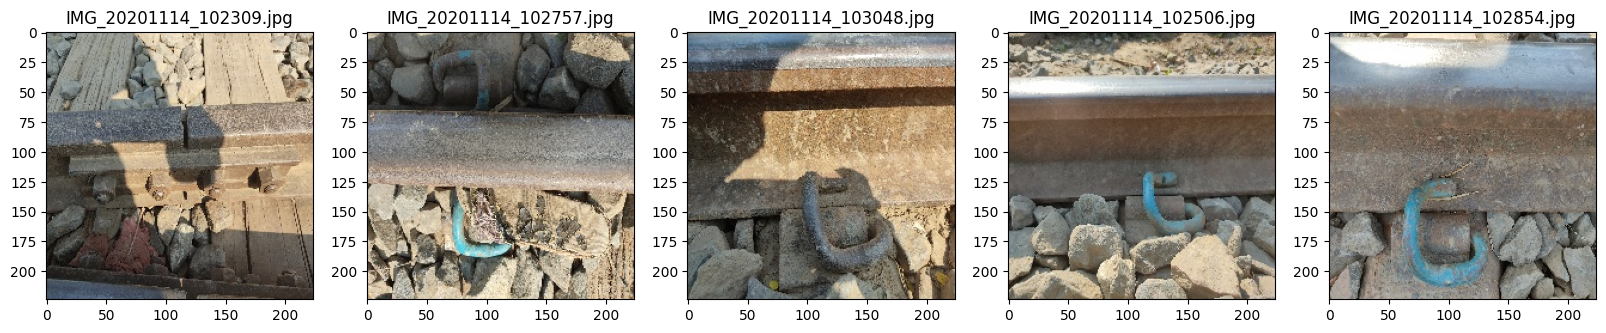

In [ ]:
plt.figure(figsize=(20,20))
img_folder='dataset/train/Non defective'

for i in range(5):
    file = random.choice(os.listdir(img_folder))
    image_path= os.path.join(img_folder, file)
    img=mpimg.imread(image_path)
    ax=plt.subplot(1,5,i+1)
    ax.title.set_text(file)
    plt.imshow(img)

# Pixel values distribution an image

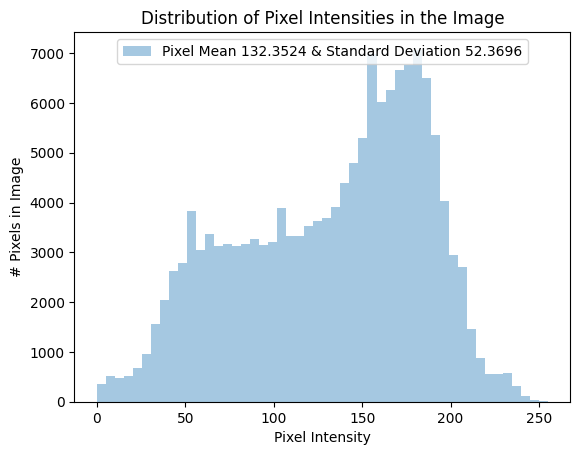

In [ ]:
# Plot a histogram of the distribution of the pixels

raw_image = plt.imread('dataset/train/Non defective/IMG_20201114_100021.jpg')


sns.distplot(raw_image.ravel(),
             label=f'Pixel Mean {np.mean(raw_image):.4f} & Standard Deviation {np.std(raw_image):.4f}', kde=False)
plt.legend(loc='upper center')
plt.title('Distribution of Pixel Intensities in the Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('# Pixels in Image')
plt.show()

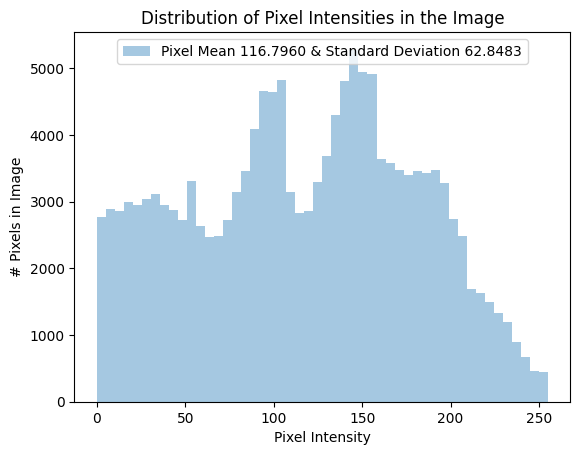

In [ ]:
raw_image = plt.imread('dataset/train/Defective/2007.05.16_-_002_Broken_rail_weld_-_Flickr_-_faxepl (1).jpg')


sns.distplot(raw_image.ravel(),
             label=f'Pixel Mean {np.mean(raw_image):.4f} & Standard Deviation {np.std(raw_image):.4f}', kde=False)
plt.legend(loc='upper center')
plt.title('Distribution of Pixel Intensities in the Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('# Pixels in Image')
plt.show()

# Image data preprocessing

In [ ]:
# Defining the image data generator for the training data

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True)

# Appling it on the train dataset
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(300,300),
    batch_size=16,
    color_mode='rgb',
    shuffle=True,
    seed=42,
    class_mode='categorical')

Found 299 images belonging to 2 classes.


In [ ]:
# Defining the image data generator for the validation data
val_datagen = ImageDataGenerator(rescale=1./255)

# Appling it on the val dataset
val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(300,300),
    batch_size=16,
    color_mode='rgb',
    shuffle=False,
    class_mode='categorical')

Found 62 images belonging to 2 classes.


In [ ]:
# Defining the image data generator for the test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Appling it on the test dataset
test_generator = val_datagen.flow_from_directory(
    test_path,
    target_size=(300,300), # VGG only support 224,224
    batch_size=16,
    color_mode='rgb',
    shuffle=False,
    class_mode=None)

Found 22 images belonging to 2 classes.


# ResNet50 v2

In [ ]:
base_model=ResNet50V2(input_shape=(300,300,3),weights='imagenet',include_top=False)

# freeze the base model (for transfer learning)
base_model.trainable = False

# add Fully-Connected Layers to Model
x=base_model.output
x=layers.GlobalAveragePooling2D()(x)
x=layers.Dense(128,activation='relu')(x)  # FC layer
preds=layers.Dense(2,activation='softmax')(x) #final layer with softmax activation

model=models.Model(inputs=base_model.input,outputs=preds)

# printing the summary of the model
model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 306, 306,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 150, 150,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 152, 152,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 75, 75,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 75, 75,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 75, 75,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 75, 75,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 75, 75,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 75, 75,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 77, 77,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 75, 75,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 75, 75,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 75, 75,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 75, 75,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 75, 75,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 75, 75,    │          0 │ conv2_block1_0_c

 Total params: 23,827,330 (90.89 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [ ]:
# compiling the model
model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
# Adam(learning_rate=0.01)

In [ ]:
STEP_SIZE_TRAIN=train_generator.n//train_generator.batch_size  # 299/16
STEP_SIZE_VAL  =val_generator.n//val_generator.batch_size
STEP_SIZE_TEST =test_generator.n//test_generator.batch_size
num_epochs = 30

In [ ]:
# training the model
history = model.fit(train_generator,steps_per_epoch=STEP_SIZE_TRAIN,epochs=num_epochs,
                    validation_data=val_generator, validation_steps=STEP_SIZE_VAL)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.5628 - loss: 0.7839 - val_accuracy: 0.5208 - val_loss: 0.7801
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 308ms/step - accuracy: 0.7500 - loss: 0.5763 - val_accuracy: 0.6250 - val_loss: 0.6290
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 565ms/step - accuracy: 0.6985 - loss: 0.6076 - val_accuracy: 0.7917 - val_loss: 0.5097
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6875 - loss: 0.4981 - val_accuracy: 0.7708 - val_loss: 0.5259
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 592ms/step - accuracy: 0.7735 - loss: 0.4161 - val_accuracy: 0.5625 - val_loss: 0.6399
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8125 - loss: 0.3610 - val_accuracy: 0.5833 - val_loss: 0.6190
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 581ms/step - accuracy: 0.7867 - loss: 0.4340 - val_accuracy: 0.8750 - val_loss: 0.3936
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8125 - loss: 0.4944 - val_accuracy: 0.89

In [ ]:
# saving the model
#model.save('model_resnet.keras')
model.save('model_resnet.h5')

In [ ]:
# plotting the accuracy of the trained model
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
# plotting the loss of the trained model
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
# model evaluation

predY=model.predict(test_generator)
y_pred = np.argmax(predY,axis=1)
y_actual = test_generator.classes

# printing the confusion matrix
cm = confusion_matrix(y_actual, y_pred)
print(cm)

In [ ]:
# printing the classificaion report
from sklearn.metrics import precision_score, f1_score,accuracy_score,recall_score,classification_report

labels = ['Defective', 'Non defective']
print(classification_report(y_actual, y_pred, target_names=labels))